# Diagnostics from the log files

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('/glade/work/fengzhu/Projects/paper-MCO_iCESM/notebooks')
import numpy as np
import x4c
import matplotlib.pyplot as plt
print(x4c.__version__)

2026.6.11


## Plotting

In [ ]:
casename = 'b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005'

L = {}
L['3xCO2'] = x4c.Logs(
    f'/glade/campaign/univ/ubrn0018/fengzhu/CESM_output/archive/{casename}/logs',
    comp='ocn',
    # load_num=-10,  # the last n files
)

casename = 'b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.1.5xCO2.005'
L['1.5xCO2'] = x4c.Logs(
    f'/glade/campaign/univ/ubrn0018/fengzhu/CESM_output/archive/{casename}/logs',
    comp='ocn',
    # load_num=-10,  # the last n files
)

# casename = 'b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.PI.tuning.110'
# L['PI'] = x4c.Logs(
#     f'/glade/campaign/univ/ubrn0018/fengzhu/CESM_output/release/{casename}/logs',
#     comp='ocn',
#     # load_num=-10,  # the last n files
# )

>>> Logs.dirpath: /glade/campaign/univ/ubrn0018/fengzhu/CESM_output/archive/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005/logs
>>> 451 Logs.paths:
Start: ocn.log.2682906.desched1.231221-232436.gz
End: ocn.log.4610617.desched1.240527-034410.gz
>>> Logs.dirpath: /glade/campaign/univ/ubrn0018/fengzhu/CESM_output/archive/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.1.5xCO2.005/logs
>>> 275 Logs.paths:
Start: ocn.log.3770172.desched1.240309-201624.gz
End: ocn.log.5283651.desched1.240715-084810.gz


In [3]:
for k, v in L.items():
    v.get_vars('TEMP')
    # v.get_vars(['TEMP', 'SALT'])

In [4]:
case = {}

dirpath = '/glade/campaign/univ/ubrn0018/fengzhu/CESM_output/timeseries/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.1.5xCO2.005'
case['1.5x'] = x4c.Timeseries(dirpath, grid_dict={'atm': 'ne16np4'}, cesm_ver=1)

dirpath = '/glade/campaign/univ/ubrn0018/fengzhu/CESM_output/timeseries/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005'
case['3x'] = x4c.Timeseries(dirpath, grid_dict={'atm': 'ne16np4'}, cesm_ver=1)

>>> case.root_dir: /glade/campaign/univ/ubrn0018/fengzhu/CESM_output/timeseries/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.1.5xCO2.005
>>> case.path_pattern: comp/proc/tseries/*/casename.hstr.vn.timespan.nc
>>> case.grid_dict: {'atm': 'ne16np4', 'ocn': 'g16', 'lnd': 'ne16np4', 'rof': 'ne16np4', 'ice': 'g16'}
>>> case.casename: b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.1.5xCO2.005
>>> case.paths["atm"]["cam.h0"] created
>>> case.paths["ocn"]["pop.h"] created
>>> case.paths["ocn"]["pop.h.nday1"] created
>>> case.paths["lnd"]["clm2.h0"] created
>>> case.paths["rof"]["rtm.h0"] created
>>> case.paths["rof"]["mosart.h0"] created
>>> case.paths["ice"]["cice.h"] created
>>> case.vns["atm"]["cam.h0"] created
>>> case.vns["ocn"]["pop.h"] created
>>> case.vns["ocn"]["pop.h.nday1"] created
>>> case.vns["lnd"]["clm2.h0"] created
>>> case.vns["rof"]["rtm.h0"] created
>>> case.vns["rof"]["mosart.h0"] created
>>> case.vns["ice"]["cice.h"] created
>>> case.root_dir: /glade/campaign/uni

In [49]:
%%time
da_restom_15 = case['1.5x'].calc('RESTOM:ann:gm', timespan=(1, 5000))
da_restom_15.x.to_netcdf('../data/iCESM1.3_RESTOM_1.5xCO2.nc')

>>> RESTOM is a supported derived variable.
>>> case.ds["FSNT"] already loaded; to reload, run case.load("FSNT", ..., reload=True).
>>> case.ds["FLNT"] already loaded; to reload, run case.load("FLNT", ..., reload=True).
>>> case.ds["RESTOM"] created
>>> Timespan: [0001-01-01 00:00:00, 5000-12-01 00:00:00]
>>> case.diags["RESTOM:ann:gm"] created
CPU times: user 3min 40s, sys: 15.3 s, total: 3min 55s
Wall time: 3min 39s


In [50]:
%%time
da_restom_3 = case['3x'].calc('RESTOM:ann:gm', timespan=(1, 9000))
da_restom_3.x.to_netcdf('../data/iCESM1.3_RESTOM_3xCO2.nc')

>>> RESTOM is a supported derived variable.
>>> case.ds["FSNT"] created
>>> case.ds["FLNT"] created
>>> case.ds["RESTOM"] created
>>> Timespan: [0001-01-01 00:00:00, 9000-12-01 00:00:00]
>>> case.diags["RESTOM:ann:gm"] created
CPU times: user 9min 51s, sys: 32.1 s, total: 10min 23s
Wall time: 9min 42s


In [5]:
# import xarray as xr

# dirpath = '/glade/campaign/univ/ubrn0018/proj-Miocene/Paul'
# ds = xr.open_dataset(os.path.join(dirpath, 'B.MMIOx2_C5_840_WISOon.pop.Annual.2300-2603_TEMP_timeseries.nc'))
# da = ds['TEMP']
# print(len(da.time))
# print(da.time.values[:3])
# print(da.time.values[-3:])

In [4]:
import xarray as xr

dirpath = '/glade/campaign/univ/ubrn0018/proj-Miocene/Paul'
ds = xr.open_dataset(os.path.join(dirpath, 'B.MMIOx2_C5_840_WISOon.pop.Annual.2300-2603_TEMP_timeseries.nc'))
da = ds['TEMP']

dz = x4c.open_dataset('../data/iCESM1.3_dz.nc')['dz']
TAREA = x4c.open_dataset('../data/iCESM1.3_TAREA.nc')['TAREA']
da.attrs['dz'] = dz
da.attrs['gw'] = TAREA

da_a22 = da.x.zavg(0, None).x.gm

da_restom_15 = xr.open_dataset('../data/iCESM1.3_RESTOM_1.5xCO2.nc')['RESTOM']
da_restom_3 = xr.open_dataset('../data/iCESM1.3_RESTOM_3xCO2.nc')['RESTOM']

/glade/derecho/scratch/fengzhu/tmp/ipykernel_15699/3847213284.py:4: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_dataset(os.path.join(dirpath, 'B.MMIOx2_C5_840_WISOon.pop.Annual.2300-2603_TEMP_timeseries.nc'))


In [5]:
print(da_a22.time.values[:3])
print(da_a22.time.values[-3:])

[cftime.DatetimeNoLeap(2300, 7, 16, 21, 59, 59, 999997, has_year_zero=True)
 cftime.DatetimeNoLeap(2301, 7, 16, 21, 59, 59, 999997, has_year_zero=True)
 cftime.DatetimeNoLeap(2302, 7, 16, 21, 59, 59, 999997, has_year_zero=True)]
[cftime.DatetimeNoLeap(2601, 7, 16, 21, 59, 59, 999997, has_year_zero=True)
 cftime.DatetimeNoLeap(2602, 7, 16, 21, 59, 59, 999997, has_year_zero=True)
 cftime.DatetimeNoLeap(2603, 7, 16, 21, 59, 59, 999997, has_year_zero=True)]


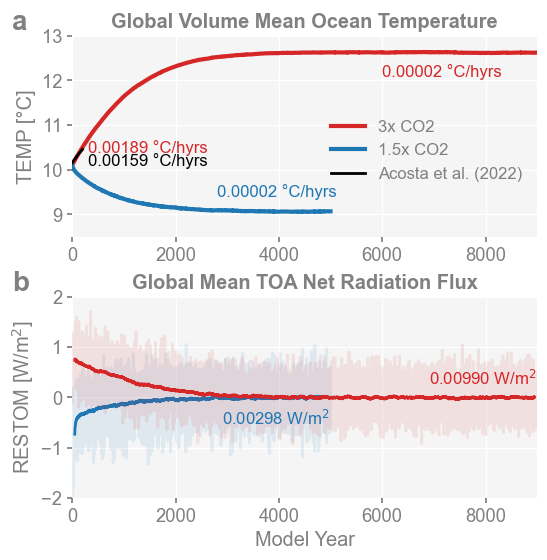

Figure saved at: "../figs/SIFig.01.pdf"


In [23]:
x4c.set_style('web', font_scale=1.2)
fig, ax = x4c.subplots(
    nrow=2, ncol=1,
    figsize=(6, 6),
    ax_loc={'TEMP': (0, 0), 'TOA': (1, 0)},
    wspace=0.3, hspace=0.3,
    annotation=True, annotation_kws={'style': '', 'loc_x': -0.13}
)

lw = 3
ax['TEMP'].plot(L['3xCO2'].df_ann.index, L['3xCO2'].df_ann['TEMP'], label='3x CO2', color='tab:red', lw=lw)
grad = (L['3xCO2'].df_ann['TEMP'].values[-1] - L['3xCO2'].df_ann['TEMP'].values[-100])/100
ax['TEMP'].text(6000, 12.2, fr'{grad:.5f} °C/hyrs', ha='left', va='center', color='tab:red', fontsize=12)

grad = (L['3xCO2'].df_ann['TEMP'].values[200] - L['3xCO2'].df_ann['TEMP'].values[100])/100
ax['TEMP'].text(300, 10.5, fr'{grad:.5f} °C/hyrs', ha='left', va='center', color='tab:red', fontsize=12)

ax['TEMP'].plot(L['1.5xCO2'].df_ann.index, L['1.5xCO2'].df_ann['TEMP'], label='1.5x CO2', color='tab:blue', lw=lw)
ax['TEMP'].set_xlim([0, 9000])
ax['TEMP'].set_ylim([8.5, 13])
ax['TEMP'].set_ylabel('TEMP [°C]')
ax['TEMP'].set_title('Global Volume Mean Ocean Temperature', weight='bold')

grad = (L['1.5xCO2'].df_ann['TEMP'].values[-1] - L['1.5xCO2'].df_ann['TEMP'].values[-100])/100
ax['TEMP'].text(2800, 9.5, fr'{grad:.5f} °C/hyrs', ha='left', va='center', color='tab:blue', fontsize=12)


# offset = -da_a22.values[100] L['3xCO2'].df_ann['TEMP'].values[0]
# print(offset)
offset = 0.04
# ax['TEMP'].plot(np.arange(len(da_a22.time[slice(100, 300)])), da_a22.values[slice(100, 300)]+0.05, color='k', label='Acosta et al. (2022)', lw=3)
ax['TEMP'].plot(np.arange(len(da_a22.time[slice(100, 300)])), da_a22.values[slice(100, 300)]+offset, color='k', label='Acosta et al. (2022)', lw=2)
grad = (da_a22.values[200] - da_a22.values[100])/100
ax['TEMP'].text(300, 10.2, fr'{grad:.5f} °C/hyrs', ha='left', va='center', color='k', fontsize=12)

ax['TEMP'].legend(ncol=1, loc='lower right', fontsize=12, bbox_to_anchor=(1, 0.2))

vals = da_restom_15.values
vals_smooth = da_restom_15.rolling(time=100, center=True).mean().data
nt = len(da_restom_15.time)
ax['TOA'].plot(np.arange(nt), vals, color='tab:blue', alpha=0.1)
ax['TOA'].plot(np.arange(nt), vals_smooth, color='tab:blue')
ax['TOA'].text(6900, 0.4, fr'{vals_smooth[-100]:.5f} W/m$^2$', ha='left', va='center', color='tab:red', fontsize=12)

vals = da_restom_3.values
vals_smooth = da_restom_3.rolling(time=100, center=True).mean().data
nt = len(da_restom_3.time)
ax['TOA'].plot(np.arange(nt), vals, color='tab:red', alpha=0.1)
ax['TOA'].plot(np.arange(nt), vals_smooth, color='tab:red')
ax['TOA'].set_ylim([-2, 2])
ax['TOA'].set_xlim([0, 9000])
ax['TOA'].set_title('Global Mean TOA Net Radiation Flux', weight='bold')
ax['TOA'].set_ylabel(r'RESTOM [W/m$^2$]')
ax['TOA'].text(2900, -0.4, fr'{vals_smooth[-100]:.5f} W/m$^2$', ha='left', va='center', color='tab:blue', fontsize=12)
ax['TOA'].set_xlabel('Model Year')

# exp_labels = {
#     'COSMOS Mid Miocene 450ppm': 'COSMOS (450ppm)',
#     'HadCM3L Mid Miocene 55SLE 400ppm': 'HadCM3L 55SLE (400ppm)',
#     'HadCM3L Mid Miocene 55SLE 560ppm': 'HadCM3L 55SLE (560ppm)',
#     'HadCM3L Mid Miocene 55SLE 850ppm': 'HadCM3L 55SLE (850ppm)',
#     'HadCM3L Mid Miocene NoICE 400ppm': 'HadCM3L NoICE (400ppm)',
#     'HadCM3L Mid Miocene NoICE 560ppm': 'HadCM3L NoICE (560ppm)',
#     'HadCM3L Mid Miocene NoICE 850ppm': 'HadCM3L NoICE (850ppm)',
# }
# clr_dict = {
#     'COSMOS Mid Miocene 450ppm': 'tab:brown',
#     'HadCM3L Mid Miocene 55SLE 400ppm': 'tab:purple',
#     'HadCM3L Mid Miocene 55SLE 560ppm': 'tab:purple',
#     'HadCM3L Mid Miocene 55SLE 850ppm': 'tab:purple',
#     'HadCM3L Mid Miocene NoICE 400ppm': 'tab:pink',
#     'HadCM3L Mid Miocene NoICE 560ppm': 'tab:pink',
#     'HadCM3L Mid Miocene NoICE 850ppm': 'tab:pink',
# }
# marker_dict = {
#     'COSMOS Mid Miocene 450ppm': 'o',
#     'HadCM3L Mid Miocene 55SLE 400ppm': 'o',
#     'HadCM3L Mid Miocene 55SLE 560ppm': 'v',
#     'HadCM3L Mid Miocene 55SLE 850ppm': '^',
#     'HadCM3L Mid Miocene NoICE 400ppm': 'o',
#     'HadCM3L Mid Miocene NoICE 560ppm': 'v',
#     'HadCM3L Mid Miocene NoICE 850ppm': '^',
# }
# for exp in exps:
#     ax['TOA'].scatter(
#         x=2000, y=da_mean.sel(exp=exp).values,
#         color=clr_dict[exp], marker=marker_dict[exp], s=10,
#         label=f'{exp_labels[exp]}: {da_mean.sel(exp=exp).values:.5f} W/m$^2$',
#     )

# ax['TOA'].legend(bbox_to_anchor=(1, 1), fontsize=12, handletextpad=-0.2, borderaxespad=0.)

x4c.showfig(fig)
x4c.savefig(fig, '../figs/SIFig.01.pdf')

IndexError: index 1001 is out of bounds for axis 0 with size 303

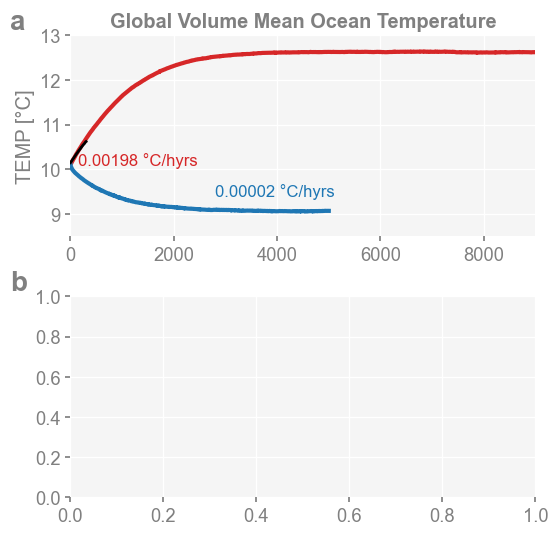

In [ ]:
x4c.set_style('web', font_scale=1.2)
fig, ax = x4c.subplots(
    nrow=2, ncol=1,
    figsize=(6, 6),
    ax_loc={'TEMP': (0, 0), 'TOA': (1, 0)},
    wspace=0.3, hspace=0.3,
    annotation=True, annotation_kws={'style': '', 'loc_x': -0.13}
)

lw = 3
ax['TEMP'].plot(L['3xCO2'].df_ann.index, L['3xCO2'].df_ann['TEMP'], label='3x CO2', color='tab:red', lw=lw)
# grad = (L['3xCO2'].df_ann['TEMP'].values[-1] - L['3xCO2'].df_ann['TEMP'].values[-100])/100
# ax['TEMP'].text(6000, 12.2, fr'{grad:.5f} °C/hyrs', ha='left', va='center', color='tab:red', fontsize=12)

grad = (L['3xCO2'].df_ann['TEMP'].values[100] - L['3xCO2'].df_ann['TEMP'].values[0])/100
ax['TEMP'].text(150, 10.2, fr'{grad:.5f} °C/hyrs', ha='left', va='center', color='tab:red', fontsize=12)

ax['TEMP'].plot(L['1.5xCO2'].df_ann.index, L['1.5xCO2'].df_ann['TEMP'], label='1.5x CO2', color='tab:blue', lw=lw)
ax['TEMP'].set_xlim([0, 9000])
ax['TEMP'].set_ylim([8.5, 13])
ax['TEMP'].set_ylabel('TEMP [°C]')
ax['TEMP'].set_title('Global Volume Mean Ocean Temperature', weight='bold')

grad = (L['1.5xCO2'].df_ann['TEMP'].values[-1] - L['1.5xCO2'].df_ann['TEMP'].values[-100])/100
ax['TEMP'].text(2800, 9.5, fr'{grad:.5f} °C/hyrs', ha='left', va='center', color='tab:blue', fontsize=12)


# offset = -da_a22.values[100] L['3xCO2'].df_ann['TEMP'].values[0]
# print(offset)
offset = 0.2
# ax['TEMP'].plot(np.arange(len(da_a22.time[slice(100, 300)])), da_a22.values[slice(100, 300)]+0.05, color='k', label='Acosta et al. (2022)', lw=3)
ax['TEMP'].plot(np.arange(len(da_a22.time)), da_a22.values+offset, color='k', label='Acosta et al. (2022)', lw=2)
grad = (da_a22.values[-1] - da_a22.values[0])/100
ax['TEMP'].text(150, 10, fr'{grad:.5f} °C/hyrs', ha='left', va='center', color='k', fontsize=12)

ax['TEMP'].legend(ncol=1, loc='lower right', fontsize=12, bbox_to_anchor=(1, 0.2))

vals = da_restom_15.values
vals_smooth = da_restom_15.rolling(time=100, center=True).mean().data
nt = len(da_restom_15.time)
ax['TOA'].plot(np.arange(nt), vals, color='tab:blue', alpha=0.1)
ax['TOA'].plot(np.arange(nt), vals_smooth, color='tab:blue')
ax['TOA'].text(6900, 0.4, fr'{vals_smooth[-100]:.5f} W/m$^2$', ha='left', va='center', color='tab:red', fontsize=12)

vals = da_restom_3.values
vals_smooth = da_restom_3.rolling(time=100, center=True).mean().data
nt = len(da_restom_3.time)
ax['TOA'].plot(np.arange(nt), vals, color='tab:red', alpha=0.1)
ax['TOA'].plot(np.arange(nt), vals_smooth, color='tab:red')
ax['TOA'].set_ylim([-2, 2])
ax['TOA'].set_xlim([0, 9000])
ax['TOA'].set_title('Global Mean TOA Net Radiation Flux', weight='bold')
ax['TOA'].set_ylabel(r'RESTOM [W/m$^2$]')
ax['TOA'].text(2900, -0.4, fr'{vals_smooth[-100]:.5f} W/m$^2$', ha='left', va='center', color='tab:blue', fontsize=12)
ax['TOA'].set_xlabel('Model Year')

# exp_labels = {
#     'COSMOS Mid Miocene 450ppm': 'COSMOS (450ppm)',
#     'HadCM3L Mid Miocene 55SLE 400ppm': 'HadCM3L 55SLE (400ppm)',
#     'HadCM3L Mid Miocene 55SLE 560ppm': 'HadCM3L 55SLE (560ppm)',
#     'HadCM3L Mid Miocene 55SLE 850ppm': 'HadCM3L 55SLE (850ppm)',
#     'HadCM3L Mid Miocene NoICE 400ppm': 'HadCM3L NoICE (400ppm)',
#     'HadCM3L Mid Miocene NoICE 560ppm': 'HadCM3L NoICE (560ppm)',
#     'HadCM3L Mid Miocene NoICE 850ppm': 'HadCM3L NoICE (850ppm)',
# }
# clr_dict = {
#     'COSMOS Mid Miocene 450ppm': 'tab:brown',
#     'HadCM3L Mid Miocene 55SLE 400ppm': 'tab:purple',
#     'HadCM3L Mid Miocene 55SLE 560ppm': 'tab:purple',
#     'HadCM3L Mid Miocene 55SLE 850ppm': 'tab:purple',
#     'HadCM3L Mid Miocene NoICE 400ppm': 'tab:pink',
#     'HadCM3L Mid Miocene NoICE 560ppm': 'tab:pink',
#     'HadCM3L Mid Miocene NoICE 850ppm': 'tab:pink',
# }
# marker_dict = {
#     'COSMOS Mid Miocene 450ppm': 'o',
#     'HadCM3L Mid Miocene 55SLE 400ppm': 'o',
#     'HadCM3L Mid Miocene 55SLE 560ppm': 'v',
#     'HadCM3L Mid Miocene 55SLE 850ppm': '^',
#     'HadCM3L Mid Miocene NoICE 400ppm': 'o',
#     'HadCM3L Mid Miocene NoICE 560ppm': 'v',
#     'HadCM3L Mid Miocene NoICE 850ppm': '^',
# }
# for exp in exps:
#     ax['TOA'].scatter(
#         x=2000, y=da_mean.sel(exp=exp).values,
#         color=clr_dict[exp], marker=marker_dict[exp], s=10,
#         label=f'{exp_labels[exp]}: {da_mean.sel(exp=exp).values:.5f} W/m$^2$',
#     )

# ax['TOA'].legend(bbox_to_anchor=(1, 1), fontsize=12, handletextpad=-0.2, borderaxespad=0.)

x4c.showfig(fig)
x4c.savefig(fig, '../figs/SIFig.01.pdf')

In [43]:

import numpy as np

# 3xCO2 first 200 years
t3 = L['3xCO2'].df_ann['TEMP'].values[:200]
yrs3 = np.arange(len(t3))

# Acosta et al. (2022) — what is plotted: slice(100, 300) of da_a22 (200 yrs), aligned to x=0..199, +0.05 offset
ta = da_a22.values[100:300] + 0.05
yrsa = np.arange(len(ta))

# Linear trend (slope) in °C per year, and per 100 yrs ("°C/hyrs")
slope3, intercept3 = np.polyfit(yrs3, t3, 1)
slopea, interceptA = np.polyfit(yrsa, ta, 1)

# Endpoint-based "rate" for parity with the way the notebook reports it
end3 = (t3[-1] - t3[0]) / (len(t3)-1) * 100
enda = (ta[-1] - ta[0]) / (len(ta)-1) * 100

print(f"3xCO2  first 200 yrs:  linear-fit slope = {slope3*100:.5f} °C/100yr   |  endpoint rate = {end3:.5f} °C/100yr")
print(f"Acosta plotted 200 yrs: linear-fit slope = {slopea*100:.5f} °C/100yr   |  endpoint rate = {enda:.5f} °C/100yr")
print()
print(f"Ratio (3xCO2 / Acosta) of linear slopes: {slope3/slopea:.2f}")
print()
print(f"3xCO2  TEMP[0], TEMP[199] = {t3[0]:.4f}, {t3[-1]:.4f}   (range {t3[-1]-t3[0]:+.4f} °C)")
print(f"Acosta TEMP[0], TEMP[199] = {ta[0]:.4f}, {ta[-1]:.4f}   (range {ta[-1]-ta[0]:+.4f} °C)")


3xCO2  first 200 yrs:  linear-fit slope = 0.19878 °C/100yr   |  endpoint rate = 0.19391 °C/100yr
Acosta plotted 200 yrs: linear-fit slope = 0.15118 °C/100yr   |  endpoint rate = 0.15066 °C/100yr

Ratio (3xCO2 / Acosta) of linear slopes: 1.31

3xCO2  TEMP[0], TEMP[199] = 10.1142, 10.5000   (range +0.3859 °C)
Acosta TEMP[0], TEMP[199] = 10.1649, 10.4648   (range +0.2998 °C)
